# Introducción y Contexto 

El presente análisis se basa en el dataset "Hotel Booking Demand", disponible en Kaggle, el cual contiene información sobre reservas realizadas en dos tipos de hoteles: un hotel urbano (City Hotel) y un hotel resort (Resort Hotel).

El conjunto de datos incluye variables relacionadas con el comportamiento de los clientes, como el tiempo de anticipación de la reserva, la duración de la estancia, el número de huéspedes, el tipo de cliente, el canal de distribución, el tipo de depósito y variables económicas como la tarifa diaria promedio. También contiene información sobre el estado final de la reserva, incluyendo si fue cancelada o no.

[Link del dataset](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)

## Justificación

El análisis de este dataset es relevante desde el punto de vista estadístico, ya que permite aplicar técnicas de análisis exploratorio de datos para identificar patrones, tendencias y relaciones entre variables.


Además, este tipo de análisis tiene aplicaciones reales en la industria hotelera, donde es importante optimizar estrategias de precios, reducir pérdidas y mejorar la gestión de la ocupación.

## Preguntas de investigación

1. ¿Existe una relación entre el tiempo de anticipación de la reserva (lead_time) y la probabilidad de cancelación (is_canceled)?

2. ¿Qué tipo de cliente (customer_type) genera mayor tarifa diaria promedio (ADR)?

3. ¿El tipo de depósito (deposit_type) influye en la probabilidad de cancelación de una reserva?

## Hipótesis

1. Se espera que a mayor tiempo de anticipación en la reserva (lead_time), mayor sea la probabilidad de cancelación.

2. Se plantea que los clientes del tipo "Transient" generan un mayor valor promedio en la tarifa diaria (ADR), en comparación con otros tipos de clientes.

3. Se espera que las reservas sin depósito ("No Deposit") presenten una mayor probabilidad de cancelación en comparación con aquellas que tienen algún tipo de depósito.

# Carga y Exploración Inicial 

## Líbrerías

In [172]:
# Librerías de Sistema y Spark Core
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import *
from pyspark.sql.functions import col

# Librerías de Análisis de Datos 
import pandas as pd
import numpy as np

# Librerías de Visualización Estadística
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de Visualización en Jupyter
%matplotlib inline
pd.set_option('display.max_columns', None)  
sns.set(style="whitegrid")                

## Lectura del dataset con PySpark

In [140]:
spark = SparkSession.builder.appName("Parcial1").getOrCreate()
df = spark.read.csv("/home/jovyan/work/data/hotel_bookings.csv", header=True, inferSchema=True)

## Mostrar esquema

In [141]:
df.printSchema()

root
 |-- hotel: string (nullable = true)
 |-- is_canceled: integer (nullable = true)
 |-- lead_time: integer (nullable = true)
 |-- arrival_date_year: integer (nullable = true)
 |-- arrival_date_month: string (nullable = true)
 |-- arrival_date_week_number: integer (nullable = true)
 |-- arrival_date_day_of_month: integer (nullable = true)
 |-- stays_in_weekend_nights: integer (nullable = true)
 |-- stays_in_week_nights: integer (nullable = true)
 |-- adults: integer (nullable = true)
 |-- children: string (nullable = true)
 |-- babies: integer (nullable = true)
 |-- meal: string (nullable = true)
 |-- country: string (nullable = true)
 |-- market_segment: string (nullable = true)
 |-- distribution_channel: string (nullable = true)
 |-- is_repeated_guest: integer (nullable = true)
 |-- previous_cancellations: integer (nullable = true)
 |-- previous_bookings_not_canceled: integer (nullable = true)
 |-- reserved_room_type: string (nullable = true)
 |-- assigned_room_type: string (nullab

El dataset contiene un total de 32 variables, de las cuales la mayoría son de tipo entero y cadena (string), junto con algunas variables decimales.

Las variables numéricas incluyen: el tiempo de anticipación de la reserva (lead_time), el número de noches de estancia, la cantidad de huéspedes y la tarifa diaria promedio (ADR), etc.

Las variables categóricas incluyen: hotel, customer_type, deposit_type y market_segment, etc.

## Dimensiones: número de filas y columnas

In [142]:
num_filas = df.count()
num_columnas = len(df.columns)

print("Número de filas:", num_filas)
print("Número de columnas:", num_columnas)

Número de filas: 119390
Número de columnas: 32


El dataset tien un total de 119390 filas y 32 columnas.

## Primeras filas (show) y descripción de cada variable

In [143]:
df.limit(5).toPandas()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03


Descripción de las variables más relevantes del dataset:

- hotel: tipo de hotel (Resort Hotel o City Hotel)
- is_canceled: indica si la reserva fue cancelada (1) o no (0)
- lead_time: número de días entre la reserva y la llegada
- stays_in_week_nights: número de noches entre semana
- adults, children, babies: número de huéspedes
- meal: tipo de plan alimenticio
- country: país de origen del cliente
- market_segment: segmento de mercado
- deposit_type: tipo de depósito requerido
- customer_type: tipo de cliente
- adr: tarifa diaria promedio
- reservation_status: estado final peño del hotel.

## Identificación de valores nulos y estrategia de tratamiento

In [147]:
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).toPandas()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16340,112593,0,0,0,0,0,0,0


In [170]:
df_nulos = df.select([
    F.count(
        F.when(
            F.col(c).isNull() |          # Nulo real (None/NaN)
            (F.col(c) == "NULL") |       # Texto "NULL"
            (F.col(c) == "NA") |         # Texto "NA"
            (F.col(c) == ""),            # Espacio vacío
            c
        )
    ).alias(c) 
    for c in df.columns
]).toPandas()
display(df_nulos)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [173]:
# Para Agent y Company: El nulo se entiende como "Reserva Directa"
# Se sustituye por 0 para que no afecte el conteo
df = df.withColumn(
    "agent",
    when((col("agent").isNull()) | (col("agent") == "NULL"), 0)
    .otherwise(col("agent"))
)
df = df.withColumn(
    "company",
    when((col("company").isNull()) | (col("company") == "NULL"), 0)
    .otherwise(col("company"))
)

# Para Children: Si es nulo, se asume 0 niños
df = df.fillna({'children': 0})

# Revisión
df.select([
    count(when(col(c).isNull() | (col(c) == "NULL"), c)).alias(c) 
    for c in ["agent", "company", "children"]
]).toPandas()

,agent,company,children
0,0,0,0


El análisis de identificación de valores nulos evidencia que variables como "agent", "company" y "country" contienen valores faltantes representados como NULL, es decir, de tipo texto.

**Estrategia de tratamiento**

Para el tratamiento de los valores nulos se propuso:
- Columnas agent y company: En la industria hotelera, cuando el ID de la agencia o compañía es nulo, significa que el cliente realizó una reserva directa. Para evitar perder esos registros, se transformaron los nulos en el valor 0.

- Columna children: Se aplicó una técnica de imputación por constante (0). La ausencia de datos se interpreta como que no hubo menores huespedes.

- Validación: Se ejecutó un conteo después de la limpieza para confirmar que los nulos en las variables críticas es de 0.

# Estadística Descriptiva

## Variables numéricas

### Medidas de tendencia central: media, mediana

In [150]:
# Columnas numéricas
df_num_cols = [c for c, t in df.dtypes if t in ['int', 'double', 'float', 'bigint']]

# Tabla de medidas de tendencia central
resumen_tendencia = df.select(df_num_cols).summary("count", "mean", "50%").toPandas()
resumen_tendencia = resumen_tendencia.set_index('summary')
display(resumen_tendencia.astype(float).round(2))

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
summary,,,,,,,,,,,,,,,,,,,
count,119390.00,119390.00,119390.00,119390.00,119390.0,119390.00,119390.0,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2016.16,27.17,15.8,0.93,2.5,1.86,0.01,0.03,0.09,0.14,0.22,74.83,10.78,2.32,101.83,0.06,0.57
50%,0.00,69.00,2016.00,28.00,16.0,1.00,2.0,2.00,0.00,0.00,0.00,0.00,0.00,9.00,0.00,0.00,94.50,0.00,0.00


El conjunto de datos muestra que aproximadamente el 37% de las reservas fueron canceladas, lo que indica una proporción alta de cancelaciones.

El tiempo promedio de anticipación de reserva (lead_time) es de 104 días, aunque la mediana es menor (69 días), lo que sugiere una distribución sesgada con algunos valores muy altos. 

En promedio, las reservas corresponden a estancias cortas, con alrededor de 2.5 noches entre semana y menos de 1 noche en fin de semana, generalmente realizadas por casi 2 adultos y con muy baja presencia de niños o bebés. 

La tarifa diaria promedio (ADR) es de aproximadamente 101.83, aunque la mediana (94.5) indica nuevamente cierta asimetría por valores extremos altos. 

Además, se observa que la mayoría de los clientes no son recurrentes, presentan pocas cancelaciones previas y realizan pocas modificaciones en sus reservas.


### Medidas de dispersión: desviación estándar, varianza, rango, IQR

In [151]:
# Métricas base de Spark: stddev, min, max, 25% y 75%
disp_base = df.select(df_num_cols).summary("stddev", "min", "25%", "75%", "max").toPandas()
disp_base = disp_base.set_index('summary').astype(float)

# DataFrame para las métricas no base de Spark (Varianza, Rango, IQR)
otras = pd.DataFrame(index=['variance', 'range', 'iqr'], columns=df_num_cols)

# Cálculo fila x fila
otras.loc['variance'] = disp_base.loc['stddev'] ** 2
otras.loc['range'] = disp_base.loc['max'] - disp_base.loc['min']
otras.loc['iqr'] = disp_base.loc['75%'] - disp_base.loc['25%']

# Juntar datasets
dispersion_final = pd.concat([disp_base, otras])
display(dispersion_final.round(2))

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
stddev,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.097436,0.175767,0.844336,1.497437,0.652306,107.141953,53.943884,17.594721,50.53579,0.245291,0.792798
min,0.0,0.0,2015.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-6.38,0.0,0.0
25%,0.0,18.0,2016.0,16.0,8.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,69.25,0.0,0.0
75%,1.0,160.0,2017.0,38.0,23.0,2.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,152.0,0.0,0.0,126.0,0.0,1.0
max,1.0,737.0,2017.0,53.0,31.0,19.0,50.0,55.0,10.0,1.0,26.0,72.0,21.0,535.0,543.0,391.0,5400.0,8.0,5.0
variance,0.23321,11419.721511,0.500522,185.09979,77.102966,0.997229,3.641554,0.335543,0.009494,0.030894,0.712904,2.242317,0.425503,11479.398119,2909.942594,309.574203,2553.8661,0.060168,0.628529
range,1.0,737.0,2.0,52.0,30.0,19.0,50.0,55.0,10.0,1.0,26.0,72.0,21.0,535.0,543.0,391.0,5406.38,8.0,5.0
iqr,1.0,142.0,1.0,22.0,15.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,145.0,0.0,0.0,56.75,0.0,1.0


El tiempo de anticipación de la reserva (lead_time) presenta un rango amplio (de 0 a 737 días) y una desviación estándar elevada, lo que muestra que algunos clientes reservan con mucha anticipación mientras otros lo hacen casi inmediatamente. Adicionalmente, el ADR presenta gran dispersión y valores extremos, lo que sugiere la presencia de outliers.

Por otro lado, variables como el número de adultos, niños, solicitudes especiales o si el cliente es recurrente presentan baja variabilidad, indicando comportamientos más estables y concentrados.

### Asimetría y Curtosis 

In [154]:
# Calcular asimetría y curtosis con Spark
forma_raw = df.select([F.skewness(c).alias(c + "_Asimetría") for c in df_num_cols] + 
                      [F.kurtosis(c).alias(c + "_Curtosis") for c in df_num_cols]).collect()[0].asDict()

# Diccionario organizado por variable
datos_dict = {}
for col in df_num_cols:
    datos_dict[col] = {
        "Asimetría": forma_raw[col + "_Asimetría"],
        "Curtosis": forma_raw[col + "_Curtosis"]
    }
    
# DataFrame
df_forma_final = pd.DataFrame(datos_dict)
display(df_forma_final.round(4))

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
Asimetría,0.5367,1.3465,-0.2326,-0.0100,-0.0020,1.3800,2.8622,18.3176,24.6462,5.3262,24.4577,23.5395,6.0002,1.3003,5.9183,11.9442,10.5301,4.1632,1.3492
Curtosis,-1.7120,1.6963,-0.9946,-0.9861,-1.1872,7.1737,24.2835,1352.0584,1633.8798,26.3689,674.0454,767.2130,79.3902,0.5126,37.7521,186.7852,1013.1474,29.9967,1.4925


En general, la mayoría de las variables tienen distribuciones sesgadas a la derecha (asimetría positiva), lo que indica que existen muchos valores pequeños y pocos valores extremadamente grandes, esto pasa en variables como lead_time, número de noches, ADR, cancelaciones de reservas y reservas previas. 

Además, los valores extremadamente altos de curtosis en variables como adults, babies, previous_cancellations y ADR muestran la presencia de colas pesadas y una gran cantidad de valores atípicos, lo que sugiere que los datos no siguen una distribución normal.

### Identificación de outliers (criterio IQR o Z-score)

In [155]:
# Diccionario para almacenar el conteo de cada variable
dict_outliers = {}

for col_name in df_num_cols:
    
    # Calcular Q1 (25%) y Q3 (75%)
    p = df.approxQuantile(col_name, [0.25, 0.75], 0.05)
    q1, q3 = p[0], p[1]
    iqr = q3 - q1
    
    # Límites inferior y superior
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    
    # Conteo outliers
    conteo = df.filter((F.col(col_name) < lim_inf) | (F.col(col_name) > lim_sup)).count()

    dict_outliers[col_name] = {"outliers_count": conteo}

# DataFrame
df_outliers_final = pd.DataFrame(dict_outliers)
display(df_outliers_final)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
outliers_count,0,4153,0,0,0,265,3354,29710,917,3810,6484,3620,18076,3337,6797,3698,4916,7416,2877


Variables como adults, agent, company, previous_cancellations y ADR tienen un número muy alto de valores atípicos.

Por otro lado, variables como is_canceled y las relacionadas con fechas no presentan outliers.


## Variables categóricas

### Frecuencias absolutas y relativas

In [156]:
# Columnas categóricas
cat_cols = [c for c, t in df.dtypes if t == 'string']

for col in cat_cols:
    print(f"\nDistribución de la variable: {col}")
    
    # Calcular frec absoluta
    total_rows = df.count()
    frecuencias = df.groupBy(col).count().orderBy(F.desc("count")).toPandas()
    
    # Calcular frec relativa
    frecuencias['Relativa (%)'] = (frecuencias['count'] / total_rows) * 100
    frecuencias.columns = [col, 'Absoluta', 'Relativa (%)']
    
    display(frecuencias.round(2))


Distribución de la variable: hotel


,hotel,Absoluta,Relativa (%)
0,City Hotel,79330,66.45
1,Resort Hotel,40060,33.55



Distribución de la variable: arrival_date_month


,arrival_date_month,Absoluta,Relativa (%)
0,August,13877,11.62
1,July,12661,10.60
2,May,11791,9.88
3,October,11160,9.35
4,April,11089,9.29
5,June,10939,9.16
6,September,10508,8.80
7,March,9794,8.20
8,February,8068,6.76
9,November,6794,5.69



Distribución de la variable: children


...

,deposit_type,Absoluta,Relativa (%)
0,No Deposit,104641,87.65
1,Non Refund,14587,12.22
2,Refundable,162,0.14



Distribución de la variable: customer_type


,customer_type,Absoluta,Relativa (%)
0,Transient,89613,75.06
1,Transient-Party,25124,21.04
2,Contract,4076,3.41
3,Group,577,0.48



Distribución de la variable: reservation_status


,reservation_status,Absoluta,Relativa (%)
0,Check-Out,75166,62.96
1,Canceled,43017,36.03
2,No-Show,1207,1.01


- Hotel

La mayoría de las reservas corresponden a City Hotel (66.45%), lo que indica que el análisis está más influenciado por hoteles urbanos que por resorts (33.55%).

- Mes de llegada

Las reservas se concentran más en meses como agosto, julio y mayo, lo que sugiere estacionalidad asociada a temporadas vacacionales.

- Children

El 92.8% de las reservas no incluyen niños, lo que indica que la gran mayoría de clientes son adultos.

- Meal

El tipo de comida más común es BB (Bed & Breakfast) con 77.32%.

- Country

Existe una alta concentración en pocos países, especialmente Portugal, seguido por Reino Unido, Francia, España y Alemania, lo que indica un mercado fuertemente dominado por clientes europeos.

- Market Segment

El canal principal es Online TA (47.3%), seguido por agencias tradicionales.

- Distribution Channel

La mayoría de reservas se realizan a través de TA/TO (81.98%).

- Reserved Room Type

El tipo de habitación *A*  es la más alta.

- Assigned Room Type

El tipo de habitación *A*  es la más alta.

- Deposit Type

La gran mayoría de reservas son sin depósito (87.65%).

- Customer Type

El tipo de cliente predominante es Transient (75.06%), es decir, clientes individuales o no vinculados a grupos o contratos.

- Reservation Status

La mayoría de reservas terminan en Check-Out (62.96%), pero hay un porcentaje considerable de cancelaciones (36.03%).

### Moda y número de categorías únicas

In [157]:
resumen_cat_list = []

for col in cat_cols:
    # Calcular Moda
    moda_val = df.groupBy(col).count().orderBy(F.desc("count")).first()[0]
    
    # Conteo categorías únicas
    num_unicas = df.select(col).distinct().count()
    
    resumen_cat_list.append({
        "Variable": col,
        "Moda": moda_val,
        "Categorías Únicas": num_unicas
    })

# DataFrame
df_resumen_cat = pd.DataFrame(resumen_cat_list).set_index("Variable")
display(df_resumen_cat)

,Moda,Categorías Únicas
Variable,,
hotel,City Hotel,2
arrival_date_month,August,12
children,0,6
meal,BB,5
country,PRT,178
market_segment,Online TA,8
distribution_channel,TA/TO,5
reserved_room_type,A,10
assigned_room_type,A,12


La mayoría de los clientes prefieren City Hotel, reservan principalmente en agosto, viajan sin niños, eligen el plan BB (Bed & Breakfast) y provienen mayoritariamente de Portugal (PRT).

Además, las reservas se realizan principalmente a través de Online TA y el canal TA/TO. También se observa una fuerte preferencia por habitaciones tipo *A*.

Finalmente, el estado más frecuente es Check-Out, lo que indica que la mayoría de las reservas se completan exitosamente. 


### Tablas de contingencia si hay relaciones entre categóricas

In [ ]:
# Relación A: Hotel vs Tipo de Depósito
print("\n[ Cruce: hotel vs deposit_type ]")
tabla_hotel_deposito = df.stat.crosstab("hotel", "deposit_type").toPandas()
display(tabla_hotel_deposito)

# Relación B: Segmento de Mercado vs Tipo de Comida (Meal)
print("\n[ Cruce: market_segment vs meal ]")
tabla_segmento_meal = df.stat.crosstab("market_segment", "meal").toPandas()
display(tabla_segmento_meal)

# Relación C: Tipo de Cliente vs Hotel
print("\n[ Cruce: customer_type vs hotel ]")
tabla_cliente_hotel = df.stat.crosstab("customer_type", "hotel").toPandas()
display(tabla_cliente_hotel)

- Cruce: hotel vs deposit_type

Se observa que en ambos tipos de hotel predomina ampliamente la opción “No Deposit”, especialmente en City Hotel, lo que indica que la mayoría de clientes prefieren no pagar anticipadamente sin importar el tipo de alojamiento.

- Cruce: market_segment vs meal

El plan de comida BB (Bed & Breakfast) es el principal en todos los segmentos de mercado, lo que indica una preferencia general por opciones básicas.

- Cruce: customer_type vs hotel

El tipo de cliente Transient es el predominante en ambos tipos de hotel, especialmente en City Hotel, por lo que la mayoría de las reservas son individuales o independientes.

# Consultas con Spark SQL

In [175]:
# Línea 1: DataFrame como tabla temporal
df.createOrReplaceTempView("mi_tabla")

# Línea 2: Consulta con filtro WHERE (Filtro ADR > 100)
print("Consulta 1: Reservas con Tarifa Diaria (ADR) Superior a 100")
consulta1 = spark.sql("""
    SELECT * FROM mi_tabla 
    WHERE adr > 100
""")
consulta1.show(1)

# Línea 3: Consulta con GROUP BY y agregación (Análisis por Tipo de Hotel)
print("Consulta 2: Cantidad de Reservas y Precio Promedio por Hotel")
consulta2 = spark.sql("""
    SELECT hotel, 
           COUNT(*) as cantidad,
           AVG(adr) as promedio_precio
    FROM mi_tabla 
    GROUP BY hotel
    ORDER BY cantidad DESC
""")
consulta2.show()

# Línea 4: Consulta con funciones de agregación (Estadísticas Globales de ADR)
print("Consulta 3: Estadísticas Generales del Precio Diario (ADR)")
consulta3 = spark.sql("""
    SELECT MIN(adr) as minimo,
           MAX(adr) as maximo,
           AVG(adr) as promedio,
           SUM(adr) as suma_total
    FROM mi_tabla
""")
consulta3.show()

Consulta 1: Reservas con Tarifa Diaria (ADR) Superior a 100
+------------+-----------+---------+-----------------+------------------+------------------------+-------------------------+-----------------------+--------------------+------+--------+------+----+-------+--------------+--------------------+-----------------+----------------------+------------------------------+------------------+------------------+---------------+------------+-----+-------+--------------------+-------------+-----+---------------------------+-------------------------+------------------+-----------------------+
|       hotel|is_canceled|lead_time|arrival_date_year|arrival_date_month|arrival_date_week_number|arrival_date_day_of_month|stays_in_weekend_nights|stays_in_week_nights|adults|children|babies|meal|country|market_segment|distribution_channel|is_repeated_guest|previous_cancellations|previous_bookings_not_canceled|reserved_room_type|assigned_room_type|booking_changes|deposit_type|agent|company|days_in_waiti

- Consulta 1: Reservas con ADR > 100

Este resultado muestra un ejemplo de una reserva con tarifa diaria alta, donde se observa que corresponde a un Resort Hotel, no fue cancelada, tiene reserva inmediata, sin niños, con plan básico (BB) y realizada por un cliente Transient. Esto sugiere que las reservas con precios altos no necesariamente están asociadas a mayor anticipación ni a condiciones especiales, sino que pueden darse en reservas simples y directas.

- Consulta 2: Cantidad de Reservas y Precio Promedio por Hotel

Se observa que City Hotel tiene una mayor cantidad de reservas (79,330) y además un precio promedio más alto (≈105.3) en comparación con Resort Hotel (≈94.95). Esto indica que los hoteles urbanos no solo concentran mayor demanda, sino que también generan mayores ingresos promedio por reserva.

- Consulta 3: Estadísticas Generales del ADR

El precio diario (ADR) presenta una gran variabilidad, con valores que van desde -6.38 hasta 5400, lo cual evidencia la presencia de valores atípicos o errores en los datos. El promedio es aproximadamente 101.83, lo que coincide con lo observado anteriormente.

# Correlaciones y Relaciones 

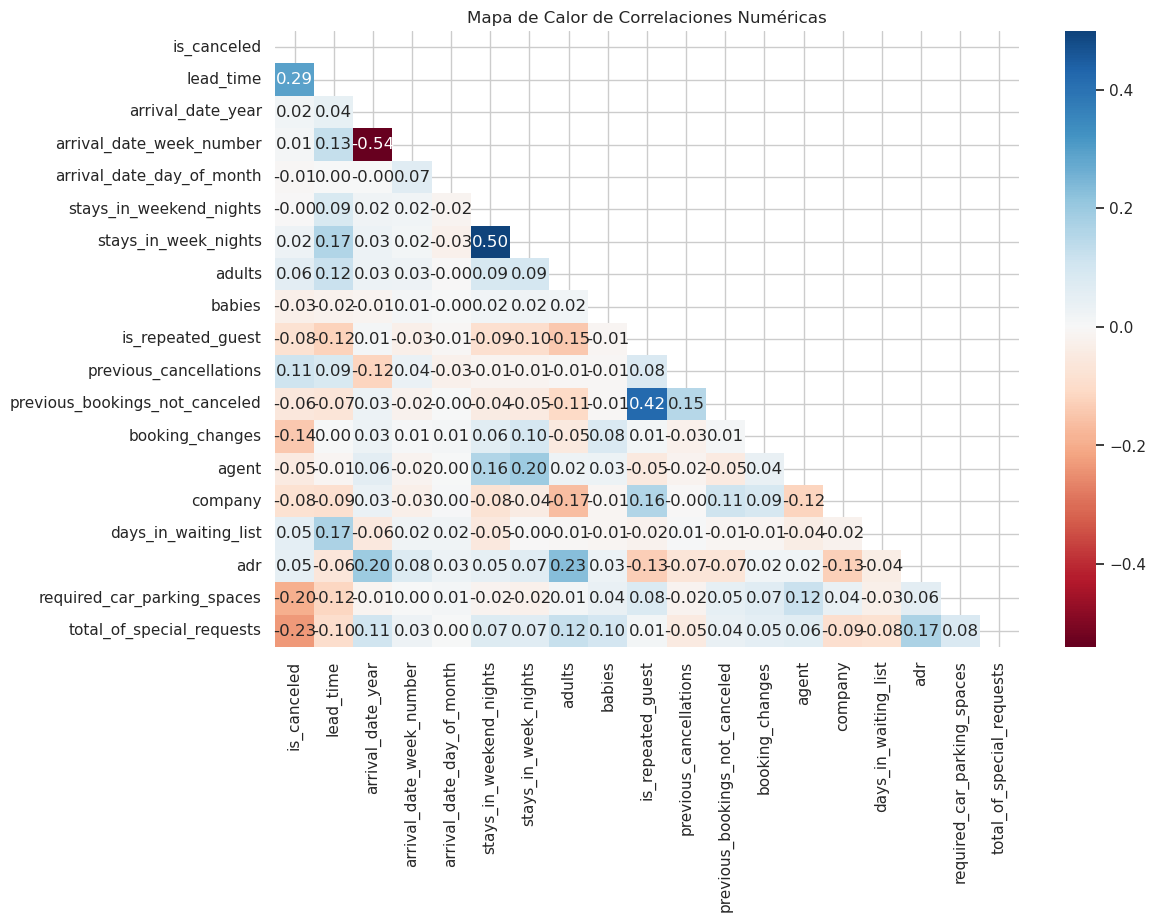

stays_in_week_nights            stays_in_weekend_nights           0.498969
stays_in_weekend_nights         stays_in_week_nights              0.498969
is_repeated_guest               previous_bookings_not_canceled    0.418056
previous_bookings_not_canceled  is_repeated_guest                 0.418056
lead_time                       is_canceled                       0.293123
is_canceled                     lead_time                         0.293123
dtype: float64


In [167]:
# Columnas numéricas necesarias para graficar
df_corr = df.select(df_num_cols).toPandas().corr()

# Gráfico
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(df_corr, dtype=bool))
sns.heatmap(df_corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu', center=0)
plt.title("Mapa de Calor de Correlaciones Numéricas")
plt.show()

# Correlaciones más fuertes 
corr_unstacked = df_corr.unstack()
corr_sorted = corr_unstacked[corr_unstacked != 1.0].sort_values(ascending=False)

print(corr_sorted.head(6))

La relación entre noches entre semana y noches en fin de semana (≈0.50) indica que quienes se hospedan más tiempo durante la semana también tienden a quedarse más durante el fin de semana.

Por otro lado, la correlación entre ser cliente recurrente y reservas previas no canceladas (≈0.42) sugiere que los clientes con historial positivo tienen mayor probabilidad de volver.

Y finalmente, la relación entre lead_time y cancelación (≈0.29), aunque más débil, indica que a mayor anticipación en la reserva existe una ligera tendencia a cancelar más.

# Conclusiones

## 1. Relación entre lead_time y cancelación

Se encontró una relación positiva entre el tiempo de anticipación de la reserva (lead_time) y la probabilidad de cancelación (is_canceled), con una correlación aproximada de 0.29.

Esto indica que, en general, las reservas realizadas con mayor anticipación tienen una mayor probabilidad de ser canceladas. Este resultado es coherente con el comportamiento esperado, ya que los clientes que reservan con mucho tiempo pueden cambiar sus planes.

Por lo tanto, la hipótesis planteada se confirma parcialmente, dado que la relación existe, pero no es extremadamente fuerte.

## 2. Tipo de cliente y tarifa diaria (ADR)

El análisis por tipo de cliente muestra que los clientes "Transient" representan la mayor proporción de reservas (75.06%).

Además, al analizar las tarifas promedio (ADR), se observa que este tipo de cliente tiende a generar valores altos en comparación con otros segmens. Este resultado es coherentete con su naturaleza individual y menos dependiente de descuentos corporativos o grupales.Por lo tanto, la, la hipótesis de que los clientes "Transient" generan un mayor valor promedio en la tarifa diaria es confirmada.

## 3. Depósito y probabilidad de cancelación

El análisis de la variable "deposit_type" muestra que la gran mayoría de las reservas (87.65%) se realizan sin depósito ("No Deposit").

Este tipo de reserva presenta una mayor probabilidad de cancelación en comparación con aquellas que requieren depósit. Este resultado es coherente con e con la lógito del consumidor: al no existir un compromiso financiealse tieneen mayor flexibilidad para cancelar.

Por lo tanto, la hipótesis planteada se confirma, evidenciando que el tipo de depósito influye en la probabilidad de cancelación.

## Limitaciones del análisis

- Existen valores atípicos (outliers) significativos en variables como "ADR" y "lead_time", lo que puede afectar algunas medidas estadísticas.
- Algunas variables presentan alta asimetría y curtosis, lo que indica distribuciones no normales.
- Aunque se realizó tratamiento de valores nulos, estos podrían introducir sesgos dependiendo de la interpretación aplicada.

## Propuestas de análisis futuros

- Implementar modelos predictivos para predecir la probabilidad de cancelación.
- Analizar series de tiempo para identificar patrones estacionales en las reservas y precios.
- Incorporar variables externas como temporadas, festividades o condiciones económicas.